In [4]:
pip install kagglehub

ERROR: Operation cancelled by user


In [5]:
import pandas as pd

In [6]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("shashanks1202/apartment-rent-data")

df = pd.read_csv('/kaggle/input/apartment-rent-data/apartments_for_rent_classified_100K/apartments_for_rent_classified_100K.csv', encoding='cp1252', sep=';')

display(df.head())

Using Colab cache for faster access to the 'apartment-rent-data' dataset.


/tmp/ipykernel_1787/539137136.py:7: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/apartment-rent-data/apartments_for_rent_classified_100K/apartments_for_rent_classified_100K.csv', encoding='cp1252', sep=';')


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,...,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,...,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

In [8]:
price_df = df[['price', 'price_display']]
kmean_df = df.drop(['id', 'category', 'title', 'body', 'time', 'has_photo', 'address', 'cityname', 'state', 'source', 'price', 'price_display', 'price_type', 'currency', 'fee'], axis=1)

In [9]:
kmean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amenities     83448 non-null  object 
 1   bathrooms     99429 non-null  float64
 2   bedrooms      99368 non-null  float64
 3   pets_allowed  39068 non-null  object 
 4   square_feet   99492 non-null  int64  
 5   latitude      99467 non-null  float64
 6   longitude     99467 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 5.3+ MB


In [10]:
kmean_df.describe()

,bathrooms,bedrooms,square_feet,latitude,longitude
count,99429.000000,99368.000000,99492.000000,99467.000000,99467.000000
mean,1.445323,1.728212,956.430688,36.947988,-91.568656
std,0.547021,0.749200,417.571522,4.599461,15.817168
min,1.000000,0.000000,101.000000,19.573800,-159.369800
25%,1.000000,1.000000,729.000000,33.746500,-104.791900
50%,1.000000,2.000000,900.000000,37.228200,-84.562300
75%,2.000000,2.000000,1115.000000,39.953000,-77.608200
max,9.000000,9.000000,50000.000000,64.833200,-68.778800


# split

In [11]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(kmean_df, test_size=0.2, random_state=42)

print(f"Training data shape: {df_train.shape}")
print(f"Testing data shape: {df_test.shape}")

Training data shape: (79593, 7)
Testing data shape: (19899, 7)


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
def engineer_text_features(df):
    """Parses text categories into numerical representations."""
    df_engineered = df.copy()

    # Extract count of amenities
    df_engineered['amenities_count'] = df_engineered['amenities'].apply(
        lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
    )

    # Binarize pets_allowed
    df_engineered['pets_allowed_bin'] = df_engineered['pets_allowed'].apply(
        lambda x: 1 if pd.notnull(x) and x != 'None' else 0
    )

    # Drop the raw text columns
    return df_engineered.drop(columns=['amenities', 'pets_allowed'])

# Apply to both sets independently
X_train_eng = engineer_text_features(df_train)
X_test_eng = engineer_text_features(df_test)

display(X_train_eng.head(3))

,bathrooms,bedrooms,square_feet,latitude,longitude,amenities_count,pets_allowed_bin
38933,1.0,3.0,468,42.2849,-71.1278,2,0
61714,2.0,2.0,1207,38.0003,-78.4636,2,0
13671,1.0,1.0,648,40.3034,-74.0707,6,0


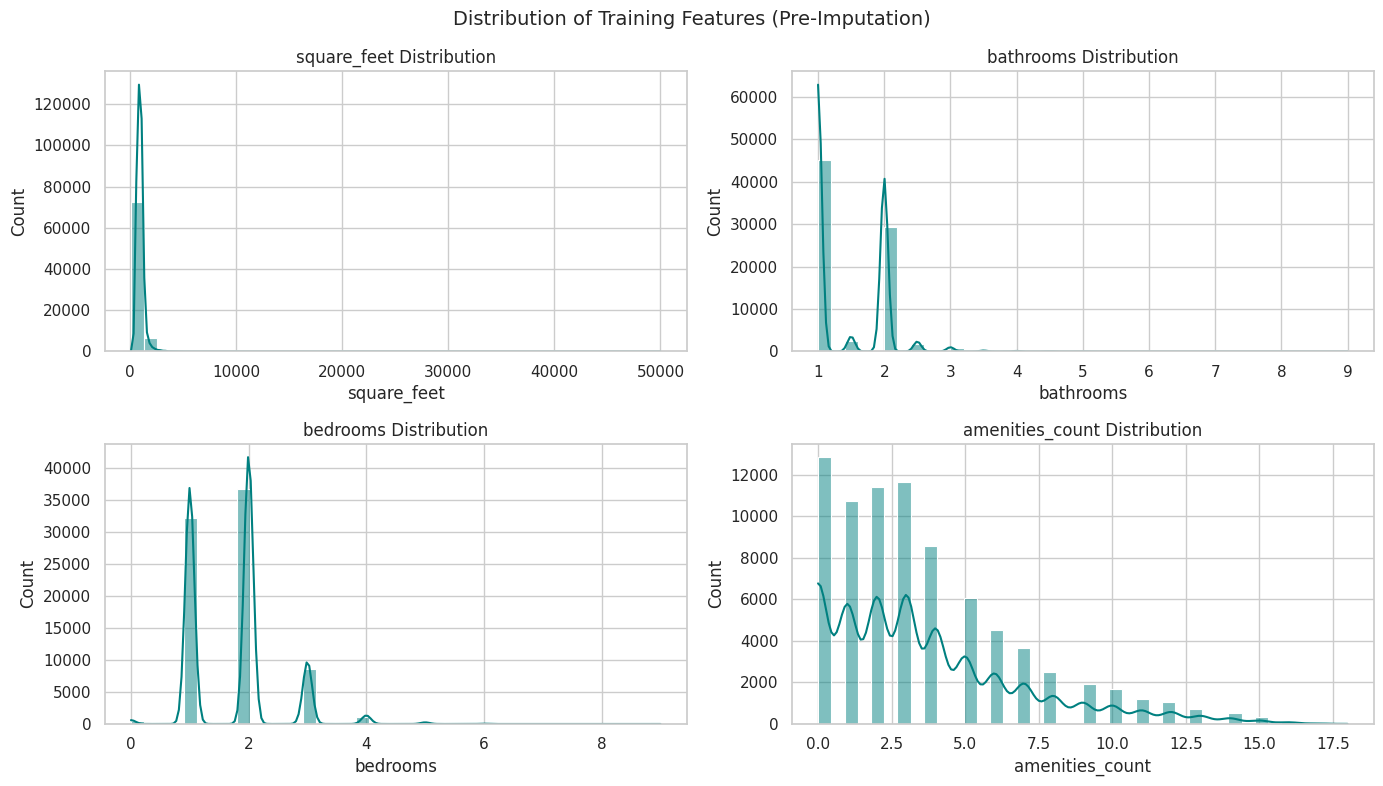

In [14]:
sns.set_theme(style="whitegrid")

numerical_cols = ['square_feet', 'bathrooms', 'bedrooms', 'amenities_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of Training Features (Pre-Imputation)', fontsize=14)

for idx, col in enumerate(numerical_cols):
    row, col_idx = divmod(idx, 2)
    sns.histplot(X_train_eng[col], bins=40, kde=True, ax=axes[row, col_idx], color='teal')
    axes[row, col_idx].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

kmeans_features = [
    'square_feet', 'bathrooms', 'bedrooms',
    'amenities_count', 'pets_allowed_bin',
    'latitude', 'longitude'
]

preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = preprocessing_pipeline.fit_transform(X_train_eng[kmeans_features])

X_test_scaled = preprocessing_pipeline.transform(X_test_eng[kmeans_features])

df_train_final = pd.DataFrame(X_train_scaled, columns=kmeans_features, index=X_train_eng.index)
df_test_final = pd.DataFrame(X_test_scaled, columns=kmeans_features, index=X_test_eng.index)

display(df_train_final.describe().round(2))

,square_feet,bathrooms,bedrooms,amenities_count,pets_allowed_bin,latitude,longitude
count,79593.00,79593.00,79593.00,79593.00,79593.00,79593.00,79593.00
mean,0.00,0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.02,-0.81,-2.31,-1.11,-0.80,-3.77,-4.28
25%,-0.54,-0.81,-0.97,-0.81,-0.80,-0.69,-0.84
50%,-0.13,-0.81,0.36,-0.20,-0.80,0.06,0.44
75%,0.38,1.02,0.36,0.41,1.24,0.65,0.88
max,115.72,13.83,9.72,4.35,1.24,6.05,1.44


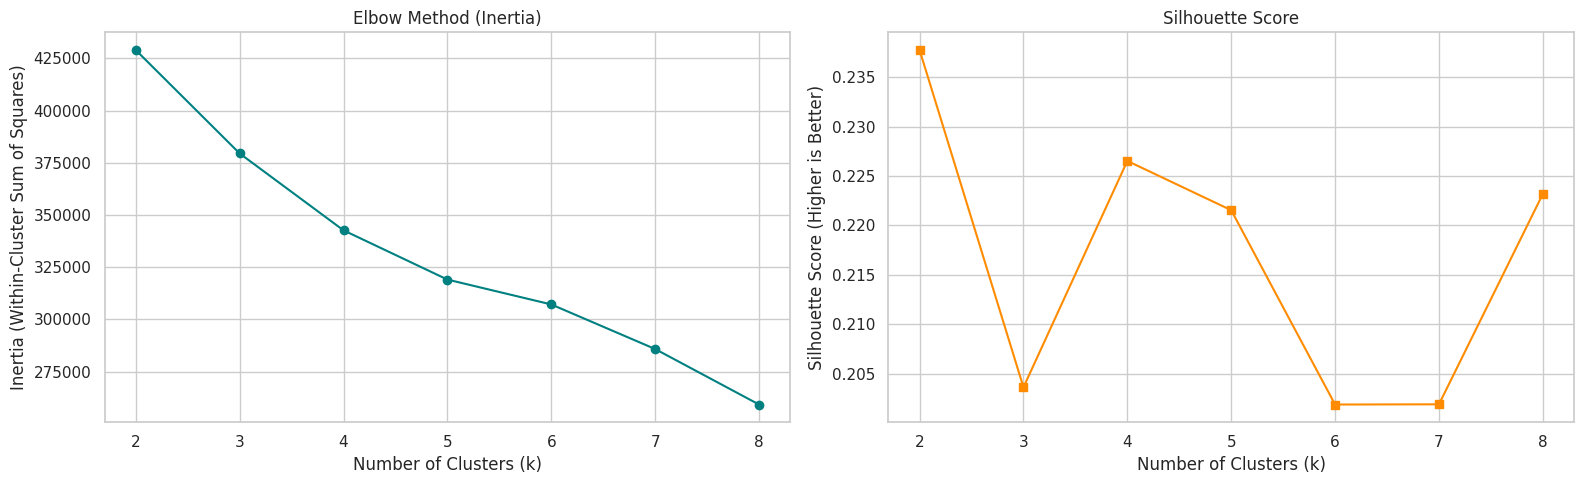

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

k_values = range(2, 9)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    cluster_labels = kmeans.fit_predict(df_train_final)

    inertia_scores.append(kmeans.inertia_)

    sil_score = silhouette_score(
        df_train_final,
        cluster_labels,
        sample_size=int(len(df_train_final)*0.1),
        random_state=42
    )
    silhouette_scores.append(sil_score)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_values, inertia_scores, marker='o', color='teal')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

axes[1].plot(k_values, silhouette_scores, marker='s', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (Higher is Better)')

plt.tight_layout()
plt.show()

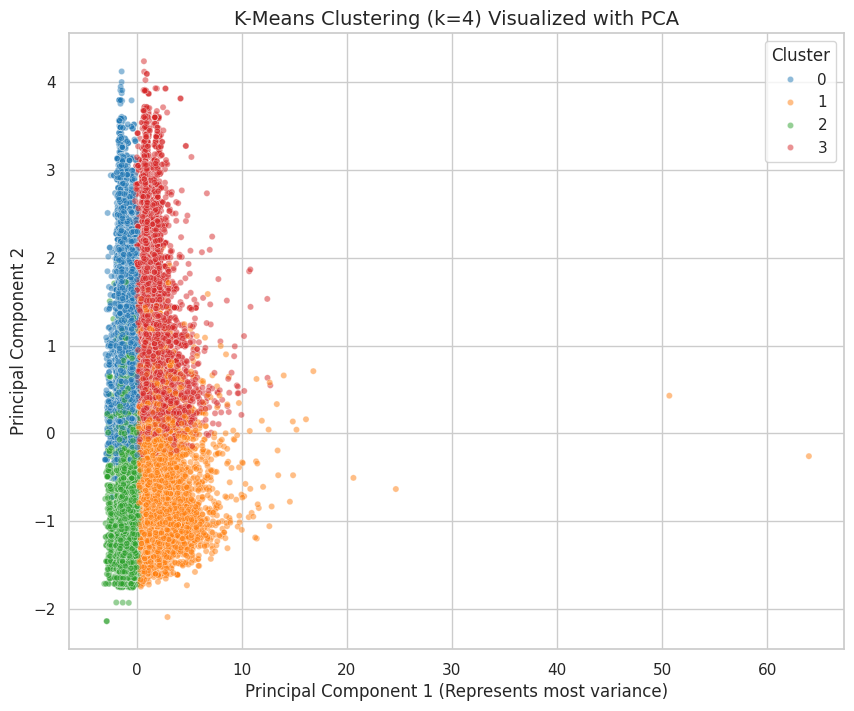

These 2D PCA components explain 50.89% of the original data's variance.


In [17]:
from sklearn.decomposition import PCA

chosen_k = 4
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')

train_labels = final_kmeans.fit_predict(df_train_final)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_train_final)

pca_df = pd.DataFrame(data=pca_components, columns=['PCA_1', 'PCA_2'])
pca_df['Cluster'] = train_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA_1',
    y='PCA_2',
    hue='Cluster',
    palette='tab10',
    data=pca_df,
    alpha=0.5,
    s=20
)

plt.title(f'K-Means Clustering (k={chosen_k}) Visualized with PCA', fontsize=14)
plt.xlabel('Principal Component 1 (Represents most variance)')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"These 2D PCA components explain {explained_variance:.2f}% of the original data's variance.")

In [18]:
profiling_df = X_train_eng[kmeans_features].copy()
profiling_df['Assigned_Cluster'] = train_labels

cluster_profiles = profiling_df.groupby('Assigned_Cluster').median()

print("Cluster Profiles (Median Values):")
display(cluster_profiles.round(2))

cluster_counts = profiling_df['Assigned_Cluster'].value_counts().sort_index()
print("\nNumber of apartments per cluster:")
print(cluster_counts)

Cluster Profiles (Median Values):


,square_feet,bathrooms,bedrooms,amenities_count,pets_allowed_bin,latitude,longitude
Assigned_Cluster,,,,,,,
0,745.0,1.0,1.0,4.0,1.0,38.27,-87.17
1,1141.0,2.0,2.0,3.0,0.0,36.74,-84.38
2,750.0,1.0,1.0,2.0,0.0,38.27,-86.17
3,1125.0,2.0,2.0,4.0,1.0,36.04,-84.43



Number of apartments per cluster:
Assigned_Cluster
0    17738
1    21421
2    26876
3    13558
Name: count, dtype: int64


In [19]:
test_labels = final_kmeans.predict(df_test_final)

X_test_eng['Assigned_Cluster'] = test_labels
X_test_eng

,bathrooms,bedrooms,square_feet,latitude,longitude,amenities_count,pets_allowed_bin,Assigned_Cluster
46085,1.0,2.0,750,42.8770,-73.1898,0,1,0
80582,1.0,1.0,649,34.0616,-118.3124,2,0,2
43550,1.0,1.0,700,39.6904,-105.0901,2,1,0
83155,2.0,2.0,903,26.5648,-81.8879,1,0,1
66628,2.0,2.0,1295,39.9559,-83.0832,3,0,1
...,...,...,...,...,...,...,...,...
18682,1.0,1.0,983,27.3671,-82.5283,4,1,0
428,1.0,1.0,566,32.0057,-102.1036,9,1,0
80318,2.0,2.0,1160,32.9108,-117.0855,1,0,1
45271,1.0,1.0,678,39.2670,-84.2921,2,1,0


In [20]:
import numpy as np
import pandas as pd

y_train = df.loc[df_train_final.index, 'price'].copy()
y_test = df.loc[df_test_final.index, 'price'].copy()

if y_train.isnull().sum() > 0:
    missing_train = y_train[y_train.isnull()].index
    y_train = y_train.drop(missing_train)
    X_train_model = df_train_final.drop(missing_train)
else:
    X_train_model = df_train_final.copy()

if y_test.isnull().sum() > 0:
    missing_test = y_test[y_test.isnull()].index
    y_test = y_test.drop(missing_test)
    X_test_model = df_test_final.drop(missing_test)
else:
    X_test_model = df_test_final.copy()


In [21]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_validate

print("Training Stacking Ensemble... This will take some computational power.\n")

# 1. Define the base models (Level 0)
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, random_state=42))
]

# 2. Define the meta-model (Level 1)
# Ridge regression is often preferred here to prevent the meta-model from overfitting
meta_model = Ridge()

# 3. Build the Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5, # 5-fold cross-validation for the meta-model training
    n_jobs=-1
)

cv_results = cross_validate(
    stacking_model,
    X_train_model,
    y_train,
    cv=5,
    scoring=['neg_mean_absolute_error', 'r2'],
    return_train_score=False
)

cv_mae = np.abs(cv_results['test_neg_mean_absolute_error'])
cv_r2 = cv_results['test_r2']

print(f"Stacking CV Mean Absolute Error (MAE): ${cv_mae.mean():.2f} (±${cv_mae.std():.2f})")
print(f"Stacking CV R-Squared: {cv_r2.mean():.4f} (±${cv_r2.std():.4f})")

# 5. Fit the final model on the entire training set
stacking_model.fit(X_train_model, y_train)

Training Stacking Ensemble... This will take some computational power.

Stacking CV Mean Absolute Error (MAE): $179.08 (±$3.18)
Stacking CV R-Squared: 0.7624 (±$0.0764)


StackingRegressor(cv=5,
                  estimators=[('rf',
                               RandomForestRegressor(n_jobs=-1,
                                                     random_state=42)),
                              ('gbr',
                               GradientBoostingRegressor(random_state=42))],
                  final_estimator=Ridge(), n_jobs=-1)

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Generate predictions on the completely UNSEEN test set
y_pred_test = stacking_model.predict(X_test_model)

# Calculate final test metrics
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("--- FINAL TEST SET PERFORMANCE ---")
print(f"Test MAE: ${test_mae:.2f}")
print(f"Test R-Squared: {test_r2:.4f}\n")

# 2. Feature Engineering: The "High Value Deal" logic
# Create a dataframe to compare predictions with actual prices
results_df = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': y_pred_test
})

# Calculate the financial difference (Positive means the apartment is underpriced)
results_df['Price_Difference'] = results_df['Predicted_Price'] - results_df['Actual_Price']
results_df['Discount_Percentage'] = (results_df['Price_Difference'] / results_df['Predicted_Price']) * 100

# Logic: A "Deal" is when the actual price is at least 15% CHEAPER than the model's predicted market value
threshold_percentage = 15.0

results_df['Is_High_Value_Deal'] = results_df['Discount_Percentage'].apply(
    lambda x: True if x >= threshold_percentage else False
)

# 3. Summary
total_test_apartments = len(results_df)
deals_found = results_df['Is_High_Value_Deal'].sum()
deal_percentage = (deals_found / total_test_apartments) * 100

print(f"Out of {total_test_apartments} unseen apartments, the model flagged {deals_found} ({deal_percentage:.1f}%) as High Value Deals.")

# Display the top 5 best deals found
top_deals = results_df[results_df['Is_High_Value_Deal']].sort_values(by='Discount_Percentage', ascending=False)
display(top_deals.head())

--- FINAL TEST SET PERFORMANCE ---
Test MAE: $175.37
Test R-Squared: 0.7510

Out of 19899 unseen apartments, the model flagged 2506 (12.6%) as High Value Deals.


,Actual_Price,Predicted_Price,Price_Difference,Discount_Percentage,Is_High_Value_Deal
29826,1475.0,23736.819108,22261.819108,93.786025,True
51823,100.0,1205.168170,1105.168170,91.702403,True
50964,565.0,5809.178077,5244.178077,90.274011,True
66807,3400.0,21573.649655,18173.649655,84.240033,True
37233,4000.0,20238.724223,16238.724223,80.235908,True


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

print("Training Baseline Linear Regression...\n")

# 1. Initialize Baseline Model
baseline_model = LinearRegression()

# 2. Cross-Validation on Training Set (Matches the Stacking Ensemble's rigorous evaluation)
baseline_cv = cross_validate(
    baseline_model,
    X_train_model,
    y_train,
    cv=5,
    scoring=['neg_mean_absolute_error', 'r2']
)
baseline_cv_mae = np.abs(baseline_cv['test_neg_mean_absolute_error'].mean())
baseline_cv_r2 = baseline_cv['test_r2'].mean()

# 3. Fit on full training data and predict on unseen test data
baseline_model.fit(X_train_model, y_train)
y_pred_baseline = baseline_model.predict(X_test_model)

# 4. Calculate Test Metrics
baseline_test_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_test_r2 = r2_score(y_test, y_pred_baseline)

print("Training Standalone Random Forest...\n")

# 5. Initialize Standalone RF Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 6. Cross-Validation on Training Set
rf_cv = cross_validate(
    rf_model,
    X_train_model,
    y_train,
    cv=5,
    scoring=['neg_mean_absolute_error', 'r2'],
    n_jobs=-1
)
rf_cv_mae = np.abs(rf_cv['test_neg_mean_absolute_error'].mean())
rf_cv_r2 = rf_cv['test_r2'].mean()

# 7. Fit on full training data and predict on unseen test data
rf_model.fit(X_train_model, y_train)
y_pred_rf = rf_model.predict(X_test_model)

# 8. Calculate Test Metrics
rf_test_mae = mean_absolute_error(y_test, y_pred_rf)
rf_test_r2 = r2_score(y_test, y_pred_rf)

# 9. Create Comparison Table
# Pulling the stacking metrics from the memory of the previous notebook cells
comparison_data = {
    'Model Variant': [
        'Baseline (Raw Linear Regression)',
        'Standalone Random Forest',
        'Stacking Ensemble (RF + GBR)'
    ],
    'CV Train MAE (5-Fold)': [
        f"${baseline_cv_mae:,.2f}",
        f"${rf_cv_mae:,.2f}",
        f"${cv_mae.mean():,.2f}"
    ],
    'CV Train R-Squared': [
        f"{baseline_cv_r2:.4f}",
        f"{rf_cv_r2:.4f}",
        f"{cv_r2.mean():.4f}"
    ],
    'Unseen Test MAE': [
        f"${baseline_test_mae:,.2f}",
        f"${rf_test_mae:,.2f}",
        f"${test_mae:,.2f}"
    ],
    'Unseen Test R-Squared': [
        f"{baseline_test_r2:.4f}",
        f"{rf_test_r2:.4f}",
        f"{test_r2:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("--- MODEL COMPARISON RESULTS ---")
display(comparison_df.style.set_properties(**{'text-align': 'left'}))


Training Baseline Linear Regression...

--- MODEL COMPARISON RESULTS ---


,Model Variant,CV Train MAE (5-Fold),CV Train R-Squared,Unseen Test MAE,Unseen Test R-Squared
0,Baseline (Raw Linear Regression),$501.40,0.1604,$499.28,0.2175
1,Stacking Ensemble (RF + GBR),$179.08,0.7624,$175.37,0.7510


# **Recommender System**

In [24]:
print("Building Master Recommender Database from ALL available data...")

# 1. Start with the original raw dataframe, but drop rows where 'price' is entirely missing
master_raw_df = df.dropna(subset=['price']).copy()

# 2. Apply our row-wise feature engineering (creating counts and bins)
master_eng_df = engineer_text_features(master_raw_df)

# 3. Scale and Impute (CRITICAL: Only use .transform(), never .fit() here!)
X_master_scaled_array = preprocessing_pipeline.transform(master_eng_df[kmeans_features])
X_master_scaled_df = pd.DataFrame(X_master_scaled_array, columns=kmeans_features, index=master_eng_df.index)

# 4. Predict Lifestyle Clusters for all 100k+ apartments
master_clusters = final_kmeans.predict(X_master_scaled_df)

# 5. Prepare Data for the Stacking Regressor (Price Predictor)
X_master_rf = X_master_scaled_df.copy()
X_master_rf['Cluster'] = master_clusters.astype(str)
X_master_rf = pd.get_dummies(X_master_rf, columns=['Cluster'])

# Align columns to ensure the dummy variables match exactly what the Stacking model saw during training
X_master_rf, _ = X_master_rf.align(X_train_model, join='right', axis=1, fill_value=0)

# 6. Predict the "Fair Market Value" for all apartments
master_predicted_prices = stacking_model.predict(X_master_rf)

# 7. Calculate the "High Value Deal" heuristic
price_differences = master_predicted_prices - master_raw_df['price'].values
discount_percentages = (price_differences / master_predicted_prices) * 100
master_is_deal = discount_percentages >= 15.0 # True if 15%+ cheaper than expected

# 8. Assemble the Final Master Recommender Database
# We copy the ENTIRE raw dataset so the frontend has access to images, descriptions, phone numbers, etc.
recommender_db = master_raw_df.copy()
recommender_db['Predicted_Cluster'] = master_clusters
recommender_db['Predicted_Fair_Price'] = master_predicted_prices
recommender_db['Is_High_Value_Deal'] = master_is_deal

# 9. Save the scaled features for Cosine Similarity calculations
scaled_features_db = X_master_scaled_df.copy()

print(f"Success! Master Database now contains {len(recommender_db)} apartments (Up from just the Test Set).")
print(f"Found {recommender_db['Is_High_Value_Deal'].sum()} 'High Value Deals' across the entire country.")

Building Master Recommender Database from ALL available data...
Success! Master Database now contains 99491 apartments (Up from just the Test Set).
Found 4738 'High Value Deals' across the entire country.


In [31]:
recommender_db.head(5)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,address,cityname,state,latitude,longitude,source,time,Predicted_Cluster,Predicted_Fair_Price,Is_High_Value_Deal
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355,0,2164.952303,False
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340,3,1251.096219,False
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332,1,1526.183505,False
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,...,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330,0,1689.941716,False
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,...,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308,0,892.930881,False


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

def get_apartment_recommendations(user_prefs, max_budget, top_n=3):
    """
    Content-Based Recommender using ML pipeline models.
    """
    # 1. Format user preferences
    user_df = pd.DataFrame([user_prefs])

    for col in kmeans_features:
        if col not in user_df.columns:
            user_df[col] = df_train_final[col].median()

    user_df = user_df[kmeans_features]

    # 2. Scale the user's input (Outputs a NumPy Array)
    user_scaled_array = preprocessing_pipeline.transform(user_df)

    # --- THE FIX: Re-wrap into a DataFrame to maintain feature names ---
    user_scaled_df = pd.DataFrame(user_scaled_array, columns=kmeans_features)

    # 3. Predict the user's Lifestyle Cluster using the DataFrame
    user_cluster = final_kmeans.predict(user_scaled_df)[0]

    # 4. Filter Phase
    valid_indices = recommender_db[
        (recommender_db['Predicted_Cluster'] == user_cluster) &
        (recommender_db['price'] <= max_budget)
    ].index

    if len(valid_indices) == 0:
        return f"No apartments found in Cluster {user_cluster} under ${max_budget}. Try increasing the budget."

    candidate_apartments = recommender_db.loc[valid_indices].copy()
    candidate_features = scaled_features_db.loc[valid_indices]

    # 5. Calculate Cosine Similarity (Cosine similarity handles raw arrays just fine)
    similarities = cosine_similarity(user_scaled_array, candidate_features)[0]
    candidate_apartments['Similarity_Score'] = similarities

    # 6. Sorting Logic
    final_recommendations = candidate_apartments.sort_values(
        by=['Is_High_Value_Deal', 'Similarity_Score'],
        ascending=[False, False]
    )

    return final_recommendations.head(top_n)

In [28]:
print("--- SCENARIO 1: MAHASISWA (User 1 & 2) ---")
# Focus: Low Budget, small space, just the basics
mahasiswa_prefs = {
    'square_feet': 500,
    'bathrooms': 1,
    'bedrooms': 1,
    'amenities_count': 2,
    'pets_allowed_bin': 0
}
mahasiswa_budget = 1000

mahasiswa_results = get_apartment_recommendations(mahasiswa_prefs, max_budget=mahasiswa_budget)
display(mahasiswa_results[['title', 'cityname', 'price', 'Predicted_Fair_Price', 'Is_High_Value_Deal', 'Similarity_Score']])


print("\n--- SCENARIO 2: ORANG BERKELUARGA (User 5) ---")
# Focus: High Budget, large space, multiple beds/baths, many amenities, pet friendly
keluarga_prefs = {
    'square_feet': 1500,
    'bathrooms': 2.5,
    'bedrooms': 3,
    'amenities_count': 10,
    'pets_allowed_bin': 1
}
keluarga_budget = 3000

keluarga_results = get_apartment_recommendations(keluarga_prefs, max_budget=keluarga_budget)
display(keluarga_results[['title', 'cityname', 'price', 'Predicted_Fair_Price', 'Is_High_Value_Deal', 'Similarity_Score']])

--- SCENARIO 1: MAHASISWA (User 1 & 2) ---


,title,cityname,price,Predicted_Fair_Price,Is_High_Value_Deal,Similarity_Score
61111,Apartment for rent in Fort Myers.,Fort Myers,800.0,1061.148550,True,0.860312
96160,This villa has plenty of windows and light.,West Palm Beach,850.0,1512.986066,True,0.859593
61095,"Apartment, $700/mo, One BR - must see to believe.",Cape Coral,700.0,838.637641,True,0.851731



--- SCENARIO 2: ORANG BERKELUARGA (User 5) ---


,title,cityname,price,Predicted_Fair_Price,Is_High_Value_Deal,Similarity_Score
58606,"Move-in condition, Two BR Two BA. Pet OK!",Naples,1295.0,1739.651668,True,0.881206
16271,Prominence Apartments Two BR Luxury Apartment ...,Sarasota,1375.0,1770.969007,True,0.868546
92301,Two BA \ Two BR \ 863 sq. ft. - in a great area.,Homestead,1200.0,1513.352348,True,0.864001


In [29]:
import joblib
import os

# Create a clean directory for your FastAPI deployment artifacts
output_dir = 'api_artifacts'
os.makedirs(output_dir, exist_ok=True)

print("Exporting Machine Learning Models...")

# 1. Save the Preprocessing Pipeline (Crucial: Contains your medians and scaling weights)
joblib.dump(preprocessing_pipeline, os.path.join(output_dir, 'preprocessing_pipeline.joblib'))
print("✓ Preprocessing Pipeline saved.")

# 2. Save the Unsupervised Model
joblib.dump(final_kmeans, os.path.join(output_dir, 'kmeans_model.joblib'))
print("✓ K-Means Model saved.")

# 3. Save the Supervised Ensemble Model
joblib.dump(stacking_model, os.path.join(output_dir, 'stacking_regressor.joblib'))
print("✓ Stacking Regressor saved.")

Exporting Machine Learning Models...
✓ Preprocessing Pipeline saved.
✓ K-Means Model saved.
✓ Stacking Regressor saved.


In [30]:
print("\nExporting Recommender Databases...")

# 1. Save the human-readable database (Used to show titles, cities, and prices to the user)
recommender_db.to_pickle(os.path.join(output_dir, 'recommender_db.pkl'))
print("✓ Recommender Database saved.")

# 2. Save the mathematically scaled features (Used for the Cosine Similarity calculation)
scaled_features_db.to_pickle(os.path.join(output_dir, 'scaled_features_db.pkl'))
print("✓ Scaled Features Database saved.")

print(f"\nAll artifacts successfully saved to the '{output_dir}/' directory. You are ready for FastAPI!")


Exporting Recommender Databases...
✓ Recommender Database saved.
✓ Scaled Features Database saved.

All artifacts successfully saved to the 'api_artifacts/' directory. You are ready for FastAPI!
